<a href="https://colab.research.google.com/github/srinivas340/ml_practice/blob/main/%20Heart%20Disease%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


/kaggle/input/heart-failure-prediction/heart.csv


In [39]:
import kagglehub
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print(f"Dataset downloaded to: {path}")
csv_path = os.path.join(path, "heart.csv")
df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'heart-failure-prediction' dataset.
Dataset downloaded to: /kaggle/input/heart-failure-prediction


In [40]:
df.shape

(918, 12)

In [41]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Data Preprocessing: One-Hot Encoding and Scaling
We will separate our features into numerical and categorical types, apply `StandardScaler` to the numerical columns, `OneHotEncoder` to the categorical columns, and split our data into training and testing sets.

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate features (X) and target (y)
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Identify categorical and numerical columns
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

# Create preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocess the data
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

print(f"Preprocessed training shape: {X_train_scaled.shape}")
print(f"Preprocessed testing shape: {X_test_scaled.shape}")

Preprocessed training shape: (734, 15)
Preprocessed testing shape: (184, 15)


### Model Training and Evaluation
Now we will import multiple classification models, train them on the preprocessed training set, make predictions, and compare their accuracies.

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

# Initialize models including XGBoost
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate each model
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc})

# Convert results to a DataFrame for visualization
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
display(results_df)

,Model,Accuracy
0,Logistic Regression,0.885870
2,Support Vector Machine,0.885870
3,K-Nearest Neighbors,0.885870
4,Gradient Boosting,0.875000
1,Random Forest,0.869565
5,XGBoost,0.858696


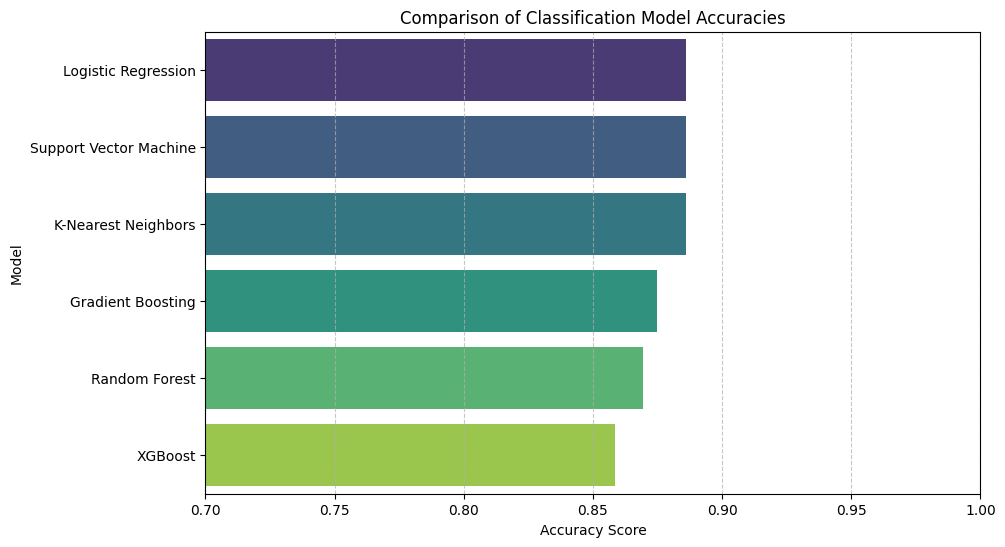

In [45]:
# Visualize the model accuracies
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.xlim(0.7, 1.0)
plt.title('Comparison of Classification Model Accuracies')
plt.xlabel('Accuracy Score')
plt.ylabel('Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Improving Accuracy: Hyperparameter Tuning & Voting Ensemble
We will perform a grid search to find optimal settings for SVM and Random Forest, and then combine our best models into an ensemble Voting Classifier.

In [46]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import VotingClassifier

# 1. Optimize Support Vector Machine (SVM)
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}
grid_svc = GridSearchCV(SVC(probability=True, random_state=42), param_grid_svc, cv=5, scoring='accuracy', n_jobs=-1)
grid_svc.fit(X_train_scaled, y_train)
best_svc = grid_svc.best_estimator_
print(f"Best SVM CV Accuracy: {grid_svc.best_score_:.4f}")

# 2. Optimize Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best Random Forest CV Accuracy: {grid_rf.best_score_:.4f}")

# 3. Build a Voting Ensemble with our best individual models
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=7) # slight tweak to KNN

voting_clf = VotingClassifier(
    estimators=[
        ('lr', logistic_model),
        ('svc', best_svc),
        ('rf', best_rf),
        ('knn', knn_model)
    ],
    voting='soft'
)

voting_clf.fit(X_train_scaled, y_train)
y_pred_ensemble = voting_clf.predict(X_test_scaled)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)

print(f"\nEnsemble Voting Classifier Test Accuracy: {ensemble_accuracy:.4f}")
print("\nClassification Report for Ensemble:")
print(classification_report(y_test, y_pred_ensemble))

Best SVM CV Accuracy: 0.8637
Best Random Forest CV Accuracy: 0.8637

Ensemble Voting Classifier Test Accuracy: 0.8913

Classification Report for Ensemble:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



### Evaluating Models with 5-Fold Cross-Validation
Instead of a single train-test split, we will use Cross-Validation on the entire training set to evaluate each model's generalizability and stability.

In [47]:
from sklearn.model_selection import cross_val_score

# Prepare all candidate models including the configured ensemble
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine (Tuned)': best_svc,
    'Random Forest (Tuned)': best_rf,
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'Voting Ensemble': voting_clf
}

# Run cross-validation
cv_results = []
for name, model in cv_models.items():
    # Evaluate using 5-fold cross validation on scaled training data
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Model': name,
        'CV Mean Accuracy': scores.mean(),
        'CV Accuracy Std': scores.std()
    })

# Convert to DataFrame and sort
cv_df = pd.DataFrame(cv_results).sort_values(by='CV Mean Accuracy', ascending=False)
display(cv_df)

,Model,CV Mean Accuracy,CV Accuracy Std
6,Voting Ensemble,0.874625,0.023230
3,K-Nearest Neighbors,0.867822,0.018754
1,Support Vector Machine (Tuned),0.863722,0.020484
2,Random Forest (Tuned),0.863722,0.026754
4,Gradient Boosting,0.855540,0.022466
0,Logistic Regression,0.854152,0.034183
5,XGBoost,0.848737,0.025120


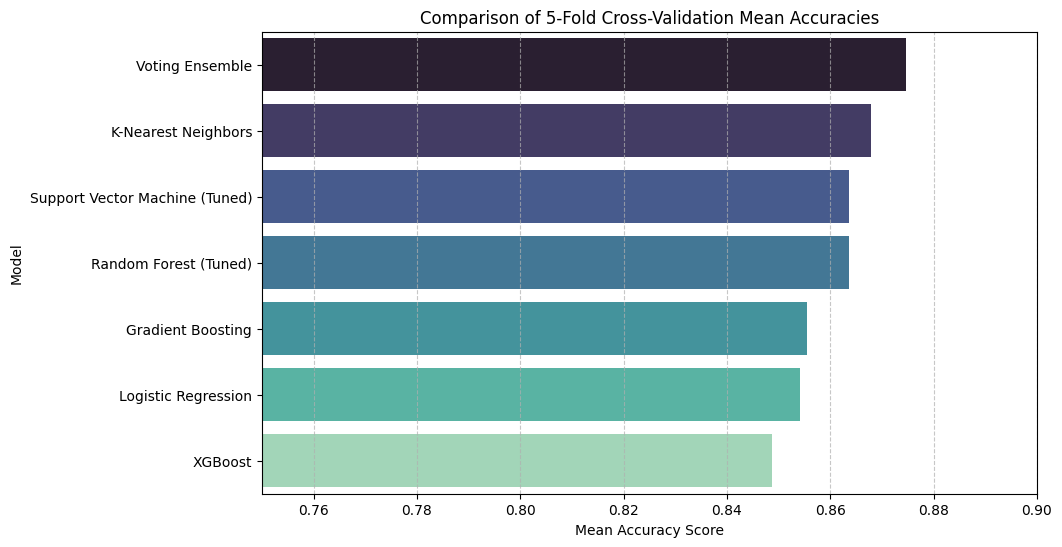

In [48]:
# Plot cross-validation results
plt.figure(figsize=(10, 6))
sns.barplot(x='CV Mean Accuracy', y='Model', data=cv_df, palette='mako')
plt.xlim(0.75, 0.90)
plt.title('Comparison of 5-Fold Cross-Validation Mean Accuracies')
plt.xlabel('Mean Accuracy Score')
plt.ylabel('Model')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Comparison of Model Accuracies: With vs. Without Cross-Validation
Let's compile both sets of results (single test split accuracy and 5-fold cross-validation mean accuracy) into a single summary table for easy comparison.

In [49]:
# Fit any models that were instantiated but not yet fitted on the full training set
logistic_model.fit(X_train_scaled, y_train)
knn_model.fit(X_train_scaled, y_train)

# 1. Gather 'Without Cross-Validation' (Test Accuracy of tuned/best models)
tuned_test_results = {
    'Logistic Regression': accuracy_score(y_test, logistic_model.predict(X_test_scaled)),
    'Support Vector Machine (Tuned)': accuracy_score(y_test, best_svc.predict(X_test_scaled)),
    'Random Forest (Tuned)': accuracy_score(y_test, best_rf.predict(X_test_scaled)),
    'K-Nearest Neighbors': accuracy_score(y_test, knn_model.predict(X_test_scaled)),
    'Gradient Boosting': accuracy_score(y_test, models['Gradient Boosting'].predict(X_test_scaled)),
    'XGBoost': accuracy_score(y_test, models['XGBoost'].predict(X_test_scaled)),
    'Voting Ensemble': accuracy_score(y_test, voting_clf.predict(X_test_scaled))
}

# 2. Merge with 'With Cross-Validation' results
summary_data = []
for name in cv_models.keys():
    cv_mean = cv_df[cv_df['Model'] == name]['CV Mean Accuracy'].values[0]
    test_acc = tuned_test_results[name]
    summary_data.append({
        'Model': name,
        'Without CV (Test Accuracy)': test_acc,
        'With CV (Mean Accuracy)': cv_mean
    })

summary_df = pd.DataFrame(summary_data).sort_values(by='With CV (Mean Accuracy)', ascending=False)
display(summary_df)

,Model,Without CV (Test Accuracy),With CV (Mean Accuracy)
6,Voting Ensemble,0.891304,0.874625
3,K-Nearest Neighbors,0.891304,0.867822
1,Support Vector Machine (Tuned),0.880435,0.863722
2,Random Forest (Tuned),0.880435,0.863722
4,Gradient Boosting,0.875000,0.855540
0,Logistic Regression,0.885870,0.854152
5,XGBoost,0.858696,0.848737


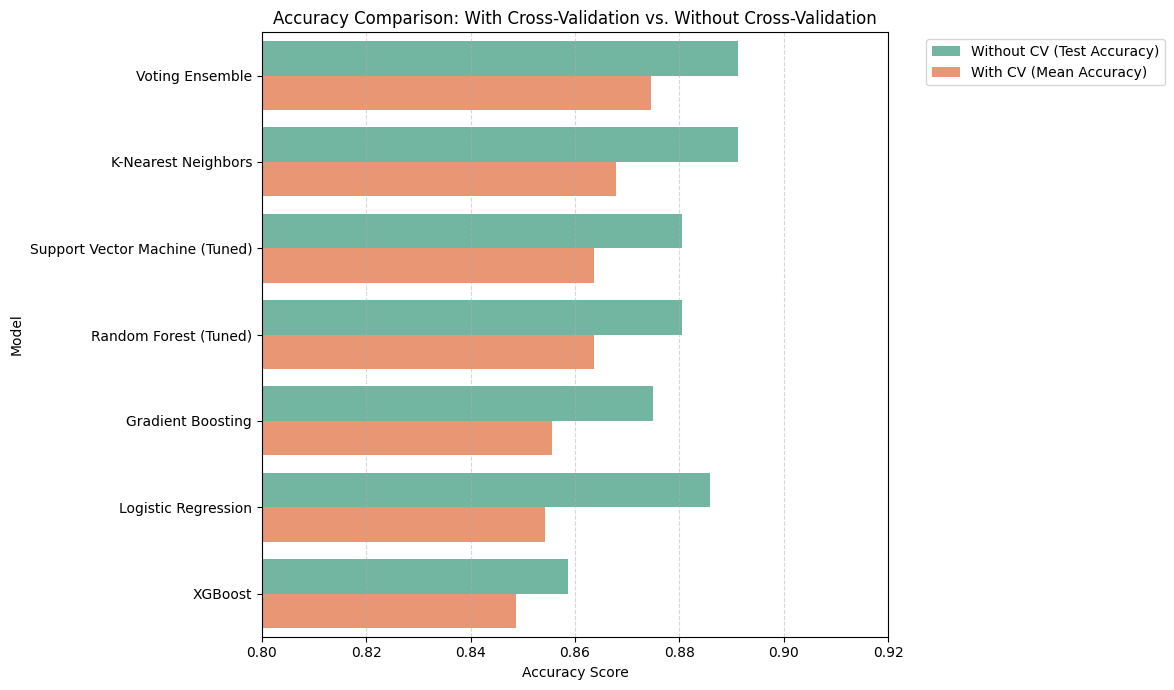

In [50]:
# Reshape data for side-by-side bar plotting
plot_df = summary_df.melt(id_vars='Model', var_name='Evaluation Method', value_name='Accuracy')

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy', y='Model', hue='Evaluation Method', data=plot_df, palette='Set2')
plt.xlim(0.80, 0.92)
plt.title('Accuracy Comparison: With Cross-Validation vs. Without Cross-Validation')
plt.xlabel('Accuracy Score')
plt.ylabel('Model')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()